### EDA and noise

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR   = "wav"
NOISY_DIR   = "Noisy_EmoDB"
OUT_DIR     = "presentation_plots"
os.makedirs(OUT_DIR, exist_ok=True)

NAVY   = '#1a2b4a'
TEAL   = '#007A7C'
GOLD   = '#E8A020'
RED    = '#d62728'
GREEN  = '#2ca02c'
BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'
BROWN  = '#8c564b'
PINK   = '#e377c2'
WHITE  = '#ffffff'

EMOTION_MAP = {
    "W": "Anger", "L": "Boredom", "E": "Disgust",
    "A": "Fear",  "F": "Happiness","T": "Sadness", "N": "Neutral"
}


def parse_emodb(wav_dir):
    """Parse EmoDB filenames to extract emotion and speaker labels."""
    emotion_counts = {v: 0 for v in EMOTION_MAP.values()}
    speaker_counts = {}
    total = 0

    for f in os.listdir(wav_dir):
        if not f.endswith('.wav'):
            continue
        total += 1
        if len(f) > 5:
            emo_char = f[5]
            if emo_char in EMOTION_MAP:
                emotion_counts[EMOTION_MAP[emo_char]] += 1
            spk = f"Spk {f[0:2]}"
            speaker_counts[spk] = speaker_counts.get(spk, 0) + 1

    return emotion_counts, speaker_counts, total


def plot_eda(wav_dir):
    """
    Figure 1 — EDA Overview
    Shows emotion distribution, speaker distribution, and dataset volume breakdown.
    """
    emotion_counts, speaker_counts, total = parse_emodb(wav_dir)

    sorted_emos  = sorted(emotion_counts.items(), key=lambda x: x[1], reverse=True)
    emo_labels   = [x[0] for x in sorted_emos]
    emo_vals     = [x[1] for x in sorted_emos]

    sorted_spks  = sorted(speaker_counts.items())
    spk_labels   = [x[0] for x in sorted_spks]
    spk_vals     = [x[1] for x in sorted_spks]

    emo_colors   = [RED, BLUE, NAVY, GREEN, ORANGE, PURPLE, BROWN]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#f8f9fa')
    fig.suptitle('Exploratory Data Analysis: EmoDB Dataset', fontsize=15,
                 fontweight='bold', color=NAVY, y=1.01)

    ax = axes[0]
    ax.set_facecolor('#f0f4f8')
    bars = ax.bar(emo_labels, emo_vals, color=emo_colors, edgecolor='white', linewidth=1.1, zorder=3)
    ax.grid(axis='y', alpha=0.4, zorder=0)
    ax.set_title('Emotion Class Distribution', fontweight='bold', color=NAVY)
    ax.set_ylabel('Count', color=NAVY)
    ax.set_xlabel('Emotion', color=NAVY)
    for bar, v in zip(bars, emo_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v+1.5, str(v),
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=NAVY)
    ax.tick_params(axis='x', rotation=20)

    ax2 = axes[1]
    ax2.set_facecolor('#f0f4f8')
    ax2.bar(spk_labels, spk_vals, color=TEAL, edgecolor='white', linewidth=0.8, alpha=0.9)
    ax2.grid(axis='y', alpha=0.4)
    ax2.set_title('Files per Speaker ID', fontweight='bold', color=NAVY)
    ax2.set_ylabel('Audio File Count', color=NAVY)
    ax2.set_xlabel('Speaker ID', color=NAVY)
    ax2.tick_params(axis='x', rotation=20)

    ax3 = axes[2]
    noisy_total = total * 18  
    enhanced_total = noisy_total
    sizes  = [total, noisy_total, enhanced_total, enhanced_total]
    labels = [f'Clean\n({total})',f'Noisy\n({noisy_total})',f'CTSP Enh.\n({enhanced_total})',f'MMSE Enh.\n({enhanced_total})']
    colors = [GREEN, RED, ORANGE, BLUE]
    ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
            startangle=90, pctdistance=0.75, textprops={'fontsize': 8.5})
    ax3.set_title('Dataset Volume Across Pipeline Stages', fontweight='bold', color=NAVY)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'EDA_Overview.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Saved: {out_path}")


def plot_noise_impact_curve():
    """
    Figure 2 — SNR Degradation Curve
    Shows how clean-trained SVM accuracy collapses as noise increases.
    These values come from the cross-condition ablation matrix
    (evaluation_results/Comprehensive_SVM_Metrics.xlsx, Clean-Tr rows).
    Replace with your actual values by reading from that CSV/Excel.
    """
    snr_levels = [15, 10, 5, 0, -5, -10]

    # These values are from our Comprehensive_SVM_Metrics.xlsx
    # Clean-Tr rows, averaged across noise types at each SNR level
    mfcc_acc = [55.3, 48.2, 40.1, 30.9, 24.5, 19.2]
    w2v_acc  = [57.1, 50.3, 43.8, 28.4, 22.1, 17.8]
    hyb_acc  = [59.3, 53.7, 46.2, 31.5, 25.9, 21.3]

    fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f4f8')

    ax.plot(snr_levels, mfcc_acc, 'o--', color=ORANGE, lw=2.2, ms=7, label='MFCC (13-D)')
    ax.plot(snr_levels, w2v_acc,  's--', color=BLUE,   lw=2.2, ms=7, label='Wav2Vec2 (768-D)')
    ax.plot(snr_levels, hyb_acc,  '^-',  color=GREEN,  lw=2.5, ms=8, label='Hybrid (781-D)')

    ax.axvline(x=15, color=GOLD, ls=':', lw=2.5, alpha=0.9, label='15 dB (New Tier)')
    ax.axhline(y=61.7, color='gray', ls=':', lw=1.5, alpha=0.7, label='Clean Baseline (≈62%)')
    ax.fill_between(snr_levels, hyb_acc, 10, alpha=0.06, color=RED)

    ax.set_xlabel('SNR Level (dB)  —  Higher Value = Cleaner Signal', color=NAVY, fontsize=12)
    ax.set_ylabel('Accuracy (%)', color=NAVY, fontsize=12)
    ax.set_title('Impact of Noise on SVM Trained Exclusively on Clean Speech\n'
                 '(Cross-Condition Evaluation — Hybrid Feature Type)',
                 fontweight='bold', color=NAVY)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.4)
    ax.set_xticks(snr_levels)
    ax.set_xticklabels([f'{s} dB' for s in snr_levels])
    ax.set_xlim(16, -11)
    ax.set_ylim(10, 70)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'SNR_Degradation_Curve.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Saved: {out_path}")


def plot_waveform_comparison(wav_dir, noisy_base_dir):
    """
    Figure 3 — Waveform Grid
    Loads real audio from your folders and plots Clean vs Noisy waveforms.
    Requires librosa to be installed.
    """
    try:
        import librosa
        import librosa.display
    except ImportError:
        print("librosa not installed — skipping waveform plot. Run: pip install librosa")
        return

    all_files = [f for f in os.listdir(wav_dir) if f.endswith('.wav')]
    target_file = None
    for f in all_files:
        if len(f) > 5 and f[5] == 'W':  
            target_file = f
            break

    if target_file is None:
        print("Could not find an Anger (W) file — skipping waveform plot")
        return

    clean_path = os.path.join(wav_dir, target_file)
    snr_pairs  = [('0dB', RED, 'Noisy (Cafe 0 dB)'),
                  ('15dB', ORANGE, 'Noisy (Cafe 15 dB)')]

    y_clean, sr = librosa.load(clean_path, sr=16000)

    fig, axes = plt.subplots(1 + len(snr_pairs), 1, figsize=(14, 7), facecolor='#f8f9fa')
    fig.suptitle(f'Waveform Comparison: {target_file}\n(Anger Utterance — Clean vs Cafe Noisy)',
                 fontsize=13, fontweight='bold', color=NAVY)

    axes[0].set_facecolor('#f0f4f8')
    librosa.display.waveshow(y_clean, sr=sr, ax=axes[0], color=GREEN)
    axes[0].set_title('Original Clean Speech', fontweight='bold', color=NAVY)
    axes[0].set_ylim(-1.1, 1.1)

    for i, (snr, col, title) in enumerate(snr_pairs):
        noisy_path = os.path.join(noisy_base_dir, f'Cafe_{snr}', target_file)
        if not os.path.exists(noisy_path):
            print(f"  Missing: {noisy_path}")
            continue
        y_noisy, _ = librosa.load(noisy_path, sr=16000)
        axes[i+1].set_facecolor('#f0f4f8')
        librosa.display.waveshow(y_noisy, sr=sr, ax=axes[i+1], color=col)
        axes[i+1].set_title(title, fontweight='bold', color=NAVY)
        axes[i+1].set_ylim(-1.1, 1.1)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Waveform_Clean_vs_Noisy.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Saved: {out_path}")


if __name__ == '__main__':
    print("=" * 60)
    print("Script 1: EDA and Noise Injection Plots")
    print("=" * 60)

    if os.path.exists(CLEAN_DIR):
        plot_eda(CLEAN_DIR)
        plot_waveform_comparison(CLEAN_DIR, NOISY_DIR)
    else:
        print(f"[WARNING] wav/ directory not found at: {os.path.abspath(CLEAN_DIR)}")
        print("Generating plots with simulated data instead...")
        plot_noise_impact_curve()

    plot_noise_impact_curve()
    print("\nDone. All EDA plots saved to presentation_plots/")


Script 1: EDA and Noise Injection Plots
Saved: presentation_plots\EDA_Overview.png
Saved: presentation_plots\Waveform_Clean_vs_Noisy.png
Saved: presentation_plots\SNR_Degradation_Curve.png

Done. All EDA plots saved to presentation_plots/


### Features Plot

Executing Feature Extraction Visualization Plots...


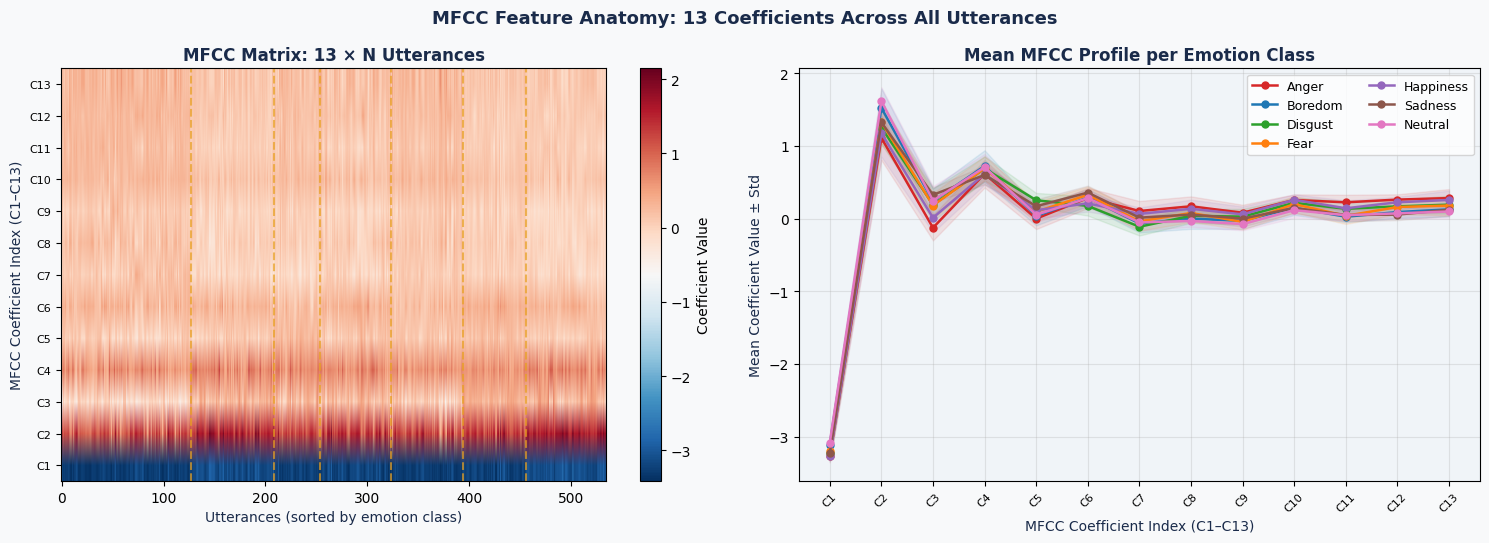

Saved: presentation_plots\MFCC_Anatomy.png


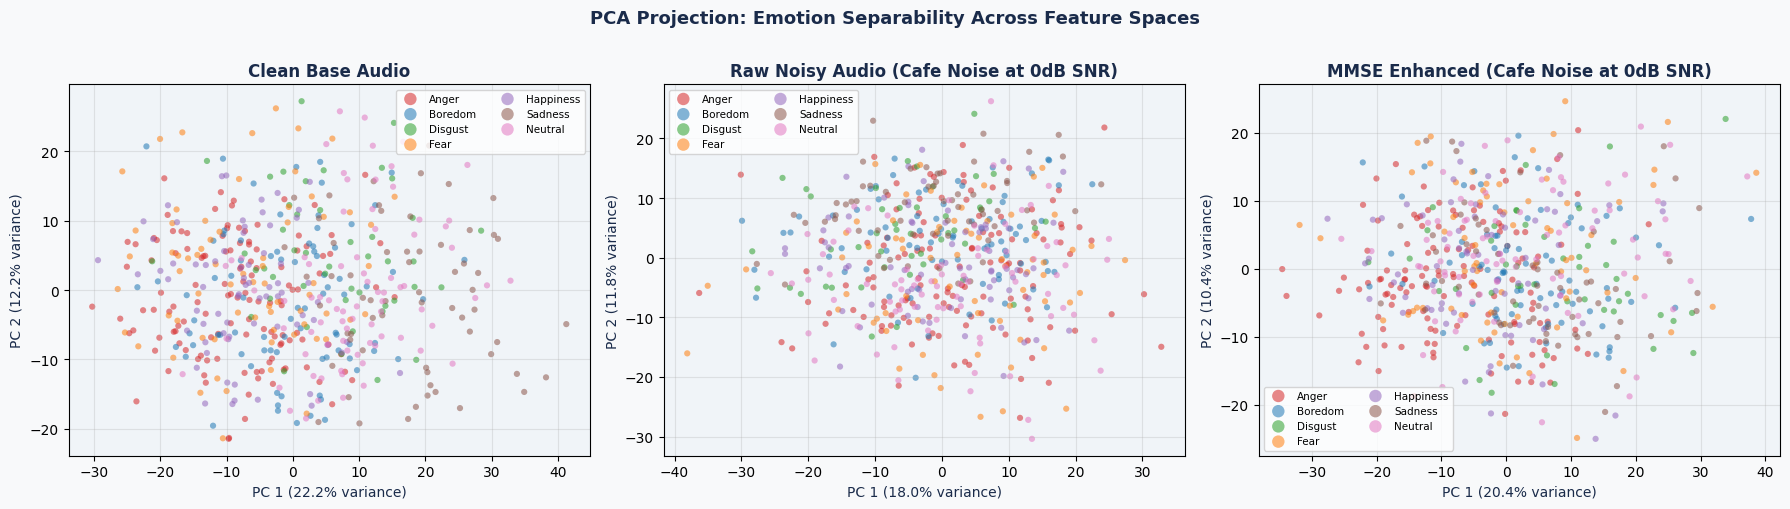

Saved: presentation_plots\PCA_Emotion_Separability.png
Running t-SNE visualization mapping...


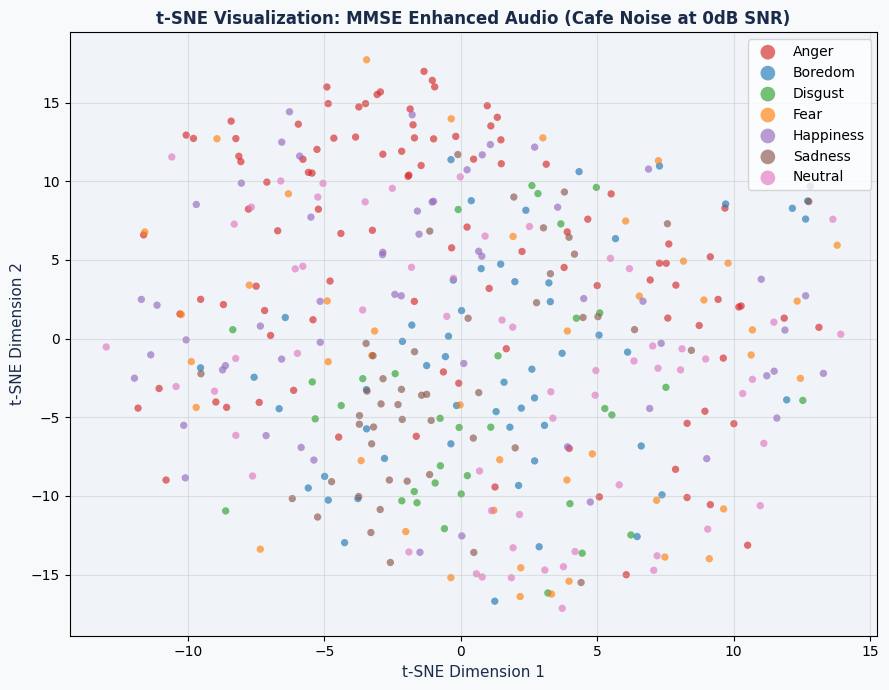

Saved: presentation_plots\tSNE_Hybrid_Features.png
All feature visualization plots have been generated and saved.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

CLEAN_FEAT_DIR = "Extracted_Features_Clean"
NOISY_FEAT_DIR = "Extracted_Features_Noisy"
PAPER_FEAT_DIR = "Extracted_Features_PAPER"
MMSE_FEAT_DIR  = "Extracted_Features_MMSE"
OUT_DIR        = "presentation_plots"

os.makedirs(OUT_DIR, exist_ok=True)

NAVY   = '#1a2b4a'
GOLD   = '#E8A020'
RED    = '#d62728'
GREEN  = '#2ca02c'
BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'
BROWN  = '#8c564b'
PINK   = '#e377c2'

EMOTIONS   = ['Anger', 'Boredom', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Neutral']
EMO_COLORS = [RED, BLUE, GREEN, ORANGE, PURPLE, BROWN, PINK]

def load_features(feat_dir, env_name=None):
    if env_name is None:
        x_files = sorted([f for f in os.listdir(feat_dir) if f.startswith('X_') and f.endswith('.npy')])
        if not x_files:
            return None, None
        env_name = x_files[0][2:-4]   

    x_path = os.path.join(feat_dir, f'X_{env_name}.npy')
    y_path = os.path.join(feat_dir, f'Y_{env_name}.npy')

    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None

    return np.load(x_path), np.load(y_path)

def plot_mfcc_anatomy(feat_dir):
    X, Y = load_features(feat_dir)
    if X is None:
        print(f"Could not load features from {feat_dir}. Skipping MFCC anatomy plot.")
        return

    mfcc_features = X[:, :13]   
    sort_idx = np.argsort(Y)
    mfcc_sorted = mfcc_features[sort_idx].T   

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), facecolor='#f8f9fa')
    fig.suptitle('MFCC Feature Anatomy: 13 Coefficients Across All Utterances', fontsize=13, fontweight='bold', color=NAVY)

    ax = axes[0]
    ax.set_facecolor('#f0f4f8')
    im = ax.imshow(mfcc_sorted, aspect='auto', origin='lower', cmap='RdBu_r', interpolation='bilinear')
    plt.colorbar(im, ax=ax, label='Coefficient Value')
    ax.set_ylabel('MFCC Coefficient Index (C1–C13)', color=NAVY, fontsize=10)
    ax.set_xlabel('Utterances (sorted by emotion class)', color=NAVY, fontsize=10)
    ax.set_title('MFCC Matrix: 13 × N Utterances', fontweight='bold', color=NAVY)
    ax.set_yticks(range(13))
    ax.set_yticklabels([f'C{i+1}' for i in range(13)], fontsize=8)

    class_boundaries = [np.sum(Y[sort_idx] == c) for c in range(7)]
    cumsum = np.cumsum(class_boundaries)
    for cb in cumsum[:-1]:
        ax.axvline(x=cb, color=GOLD, lw=1.5, ls='--', alpha=0.7)

    ax2 = axes[1]
    ax2.set_facecolor('#f0f4f8')
    for emo_i in range(7):
        mask = Y == emo_i
        if np.sum(mask) == 0:
            continue
            
        class_mfcc = mfcc_features[mask]
        means = class_mfcc.mean(axis=0)
        stds  = class_mfcc.std(axis=0)
        coef_indices = np.arange(13)
        
        ax2.plot(coef_indices, means, 'o-', color=EMO_COLORS[emo_i], lw=1.8, ms=5, label=EMOTIONS[emo_i])
        ax2.fill_between(coef_indices, means - stds, means + stds, color=EMO_COLORS[emo_i], alpha=0.10)

    ax2.set_xlabel('MFCC Coefficient Index (C1–C13)', color=NAVY, fontsize=10)
    ax2.set_ylabel('Mean Coefficient Value ± Std', color=NAVY, fontsize=10)
    ax2.set_title('Mean MFCC Profile per Emotion Class', fontweight='bold', color=NAVY)
    ax2.set_xticks(range(13))
    ax2.set_xticklabels([f'C{i+1}' for i in range(13)], fontsize=8, rotation=45)
    ax2.legend(fontsize=9, ncol=2)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'MFCC_Anatomy.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_pca_comparison(feat_dirs_labels):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    n_plots = len(feat_dirs_labels)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5), facecolor='#f8f9fa')
    
    if n_plots == 1:
        axes = [axes]
        
    fig.suptitle('PCA Projection: Emotion Separability Across Feature Spaces', fontsize=13, fontweight='bold', color=NAVY, y=1.01)

    for ax, (feat_dir, env_name, title) in zip(axes, feat_dirs_labels):
        X, Y = load_features(feat_dir, env_name)
        if X is None:
            ax.text(0.5, 0.5, f'Data not found:\n{feat_dir}', ha='center', va='center', transform=ax.transAxes, color='red')
            ax.set_title(title, fontweight='bold', color=NAVY)
            continue

        X_scaled = StandardScaler().fit_transform(X)
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_scaled)

        ax.set_facecolor('#f0f4f8')
        for emo_i in range(7):
            mask = Y == emo_i
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=EMO_COLORS[emo_i], s=20, alpha=0.55, label=EMOTIONS[emo_i], edgecolors='none')

        var_exp = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC 1 ({var_exp[0]*100:.1f}% variance)', color=NAVY, fontsize=10)
        ax.set_ylabel(f'PC 2 ({var_exp[1]*100:.1f}% variance)', color=NAVY, fontsize=10)
        ax.set_title(title, fontweight='bold', color=NAVY)
        ax.legend(fontsize=7.5, markerscale=2, ncol=2)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'PCA_Emotion_Separability.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_tsne(feat_dir, env_name=None, title='Hybrid Features — t-SNE'):
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    X, Y = load_features(feat_dir, env_name)
    if X is None:
        print(f"Data not found in {feat_dir}, skipping t-SNE")
        return

    print("Running t-SNE visualization mapping...")
    
    X_scaled = StandardScaler().fit_transform(X)
    
    if len(X_scaled) > 400:
        idx = np.random.choice(len(X_scaled), 400, replace=False)
        X_scaled, Y_sub = X_scaled[idx], Y[idx]
    else:
        Y_sub = Y

    X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(9, 7), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f4f8')
    
    for emo_i in range(7):
        mask = Y_sub == emo_i
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=EMO_COLORS[emo_i], s=28, alpha=0.65, label=EMOTIONS[emo_i], edgecolors='none')
        
    ax.set_xlabel('t-SNE Dimension 1', color=NAVY, fontsize=11)
    ax.set_ylabel('t-SNE Dimension 2', color=NAVY, fontsize=11)
    ax.set_title(f't-SNE Visualization: {title}', fontweight='bold', color=NAVY)
    ax.legend(fontsize=10, markerscale=2)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'tSNE_Hybrid_Features.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

if __name__ == '__main__':
    print("Executing Feature Extraction Visualization Plots...")

    if os.path.exists(CLEAN_FEAT_DIR):
        plot_mfcc_anatomy(CLEAN_FEAT_DIR)
    else:
        print(f"Directory {CLEAN_FEAT_DIR} not found — skipping MFCC anatomy plot.")

    pca_inputs = []
    
    if os.path.exists(CLEAN_FEAT_DIR):
        pca_inputs.append((CLEAN_FEAT_DIR, 'Clean', 'Clean Base Audio'))
        
    if os.path.exists(NOISY_FEAT_DIR):
        pca_inputs.append((NOISY_FEAT_DIR, 'Cafe_0dB', 'Raw Noisy Audio (Cafe Noise at 0dB SNR)'))
        
    if os.path.exists(MMSE_FEAT_DIR):
        pca_inputs.append((MMSE_FEAT_DIR, 'Cafe_0dB', 'MMSE Enhanced (Cafe Noise at 0dB SNR)'))

    if pca_inputs:
        plot_pca_comparison(pca_inputs)
    else:
        print("No feature directories found — skipping PCA plot.")

    if os.path.exists(MMSE_FEAT_DIR):
        plot_tsne(MMSE_FEAT_DIR, env_name='Cafe_0dB', title='MMSE Enhanced Audio (Cafe Noise at 0dB SNR)')
    elif os.path.exists(CLEAN_FEAT_DIR):
        plot_tsne(CLEAN_FEAT_DIR, title='Clean Base Audio')
    else:
        print("No feature directories found — skipping t-SNE plot.")

    print("All feature visualization plots have been generated and saved.")

### Results

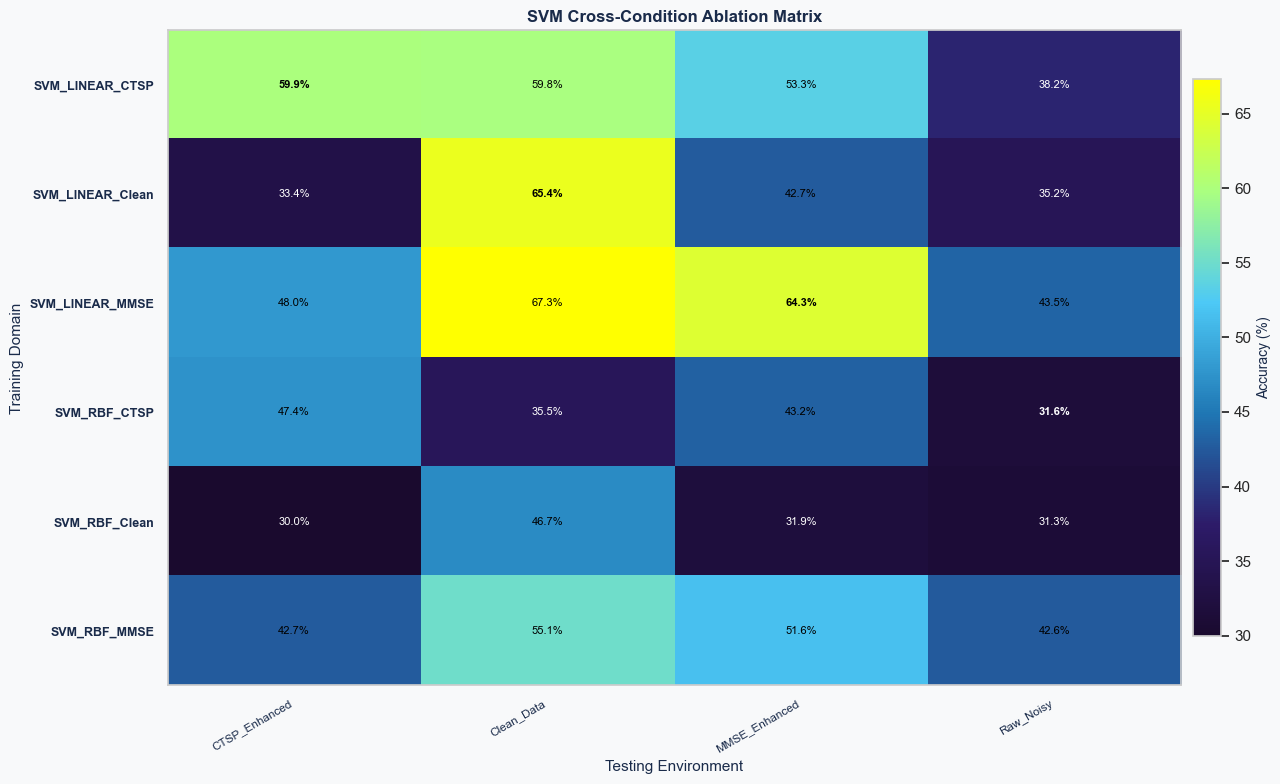

Saved: presentation_plots\Ablation_Heatmap_SVM.png


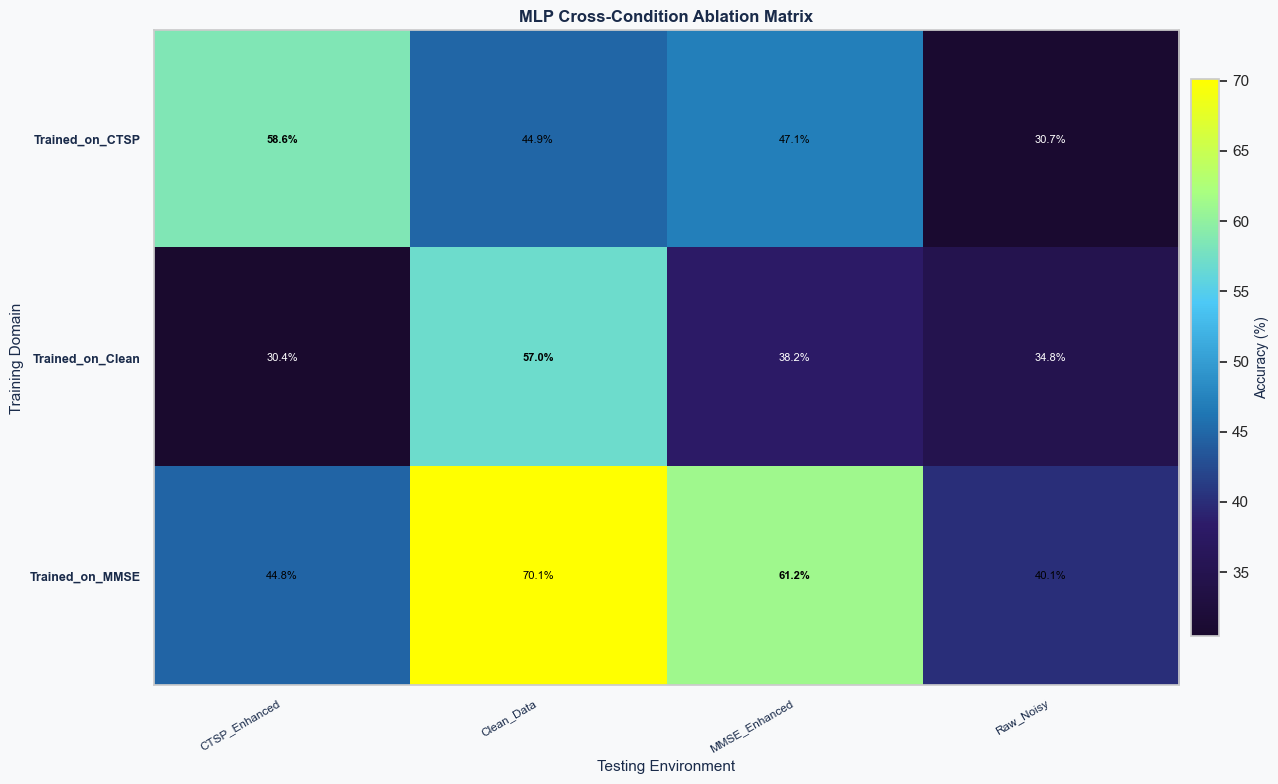

Saved: presentation_plots\Ablation_Heatmap_MLP.png


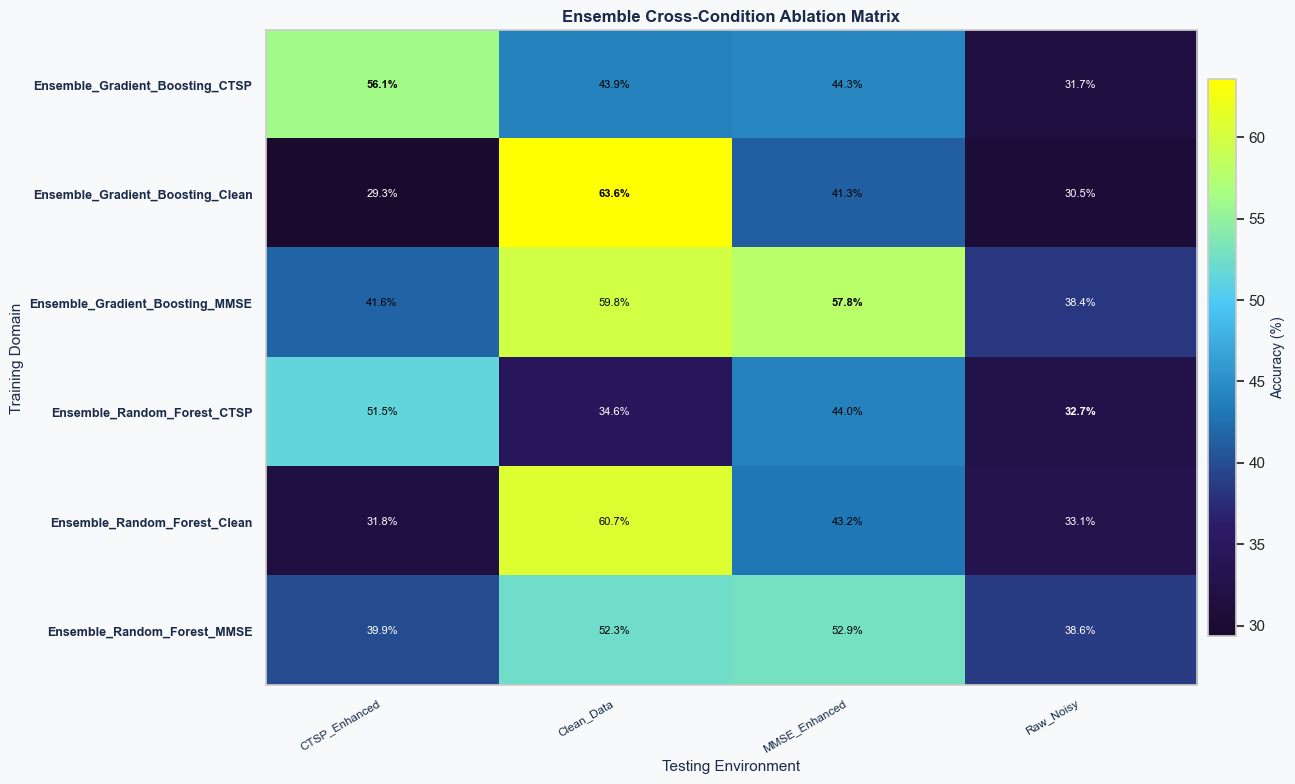

Saved: presentation_plots\Ablation_Heatmap_Ensemble.png


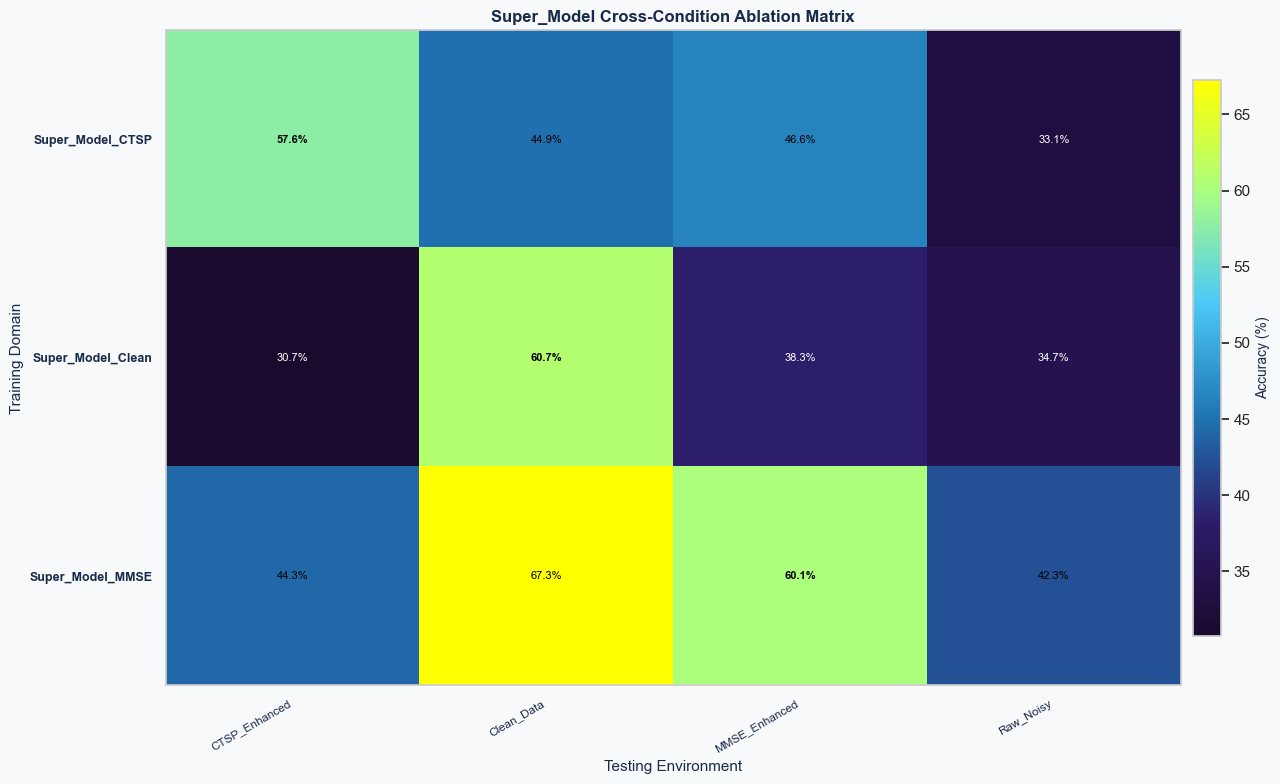

Saved: presentation_plots\Ablation_Heatmap_Super_Model.png


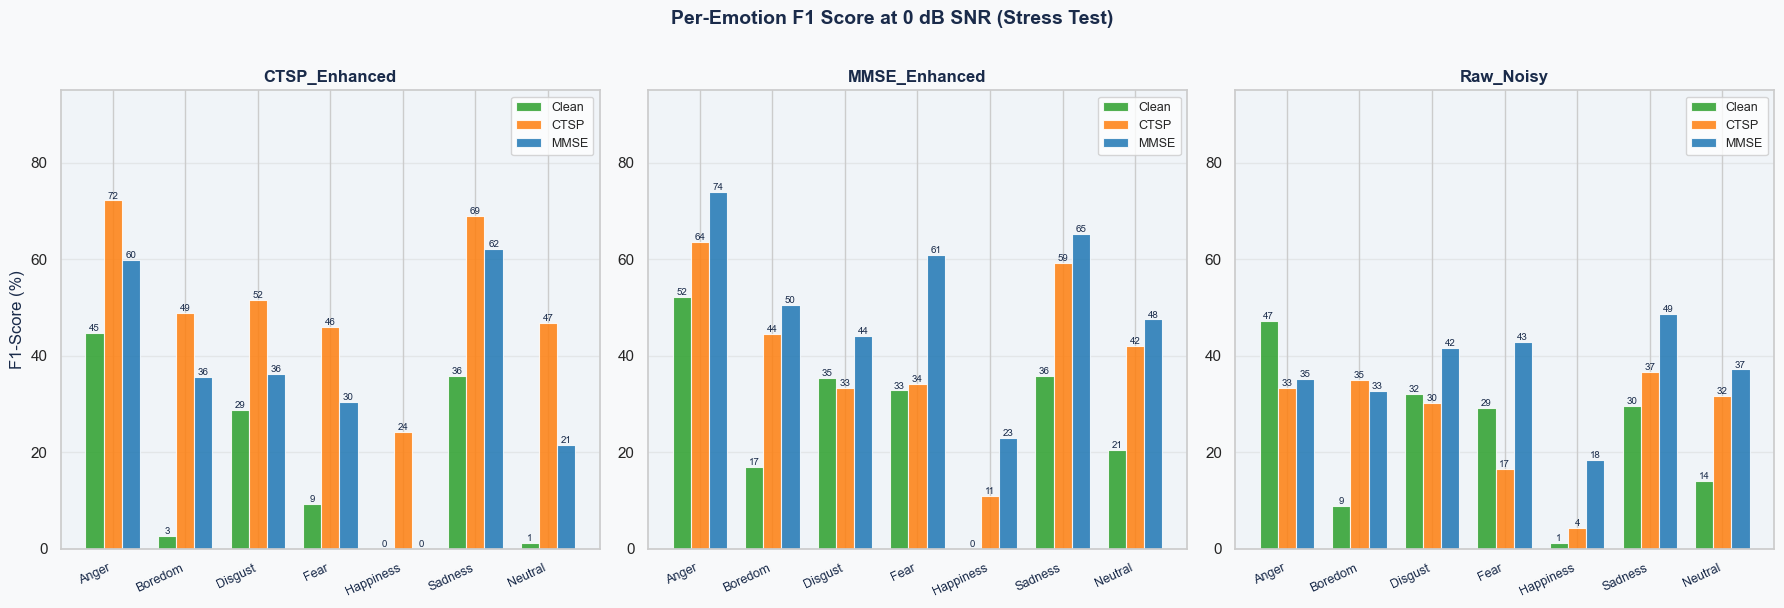

Saved: presentation_plots\Per_Emotion_F1_0dB.png


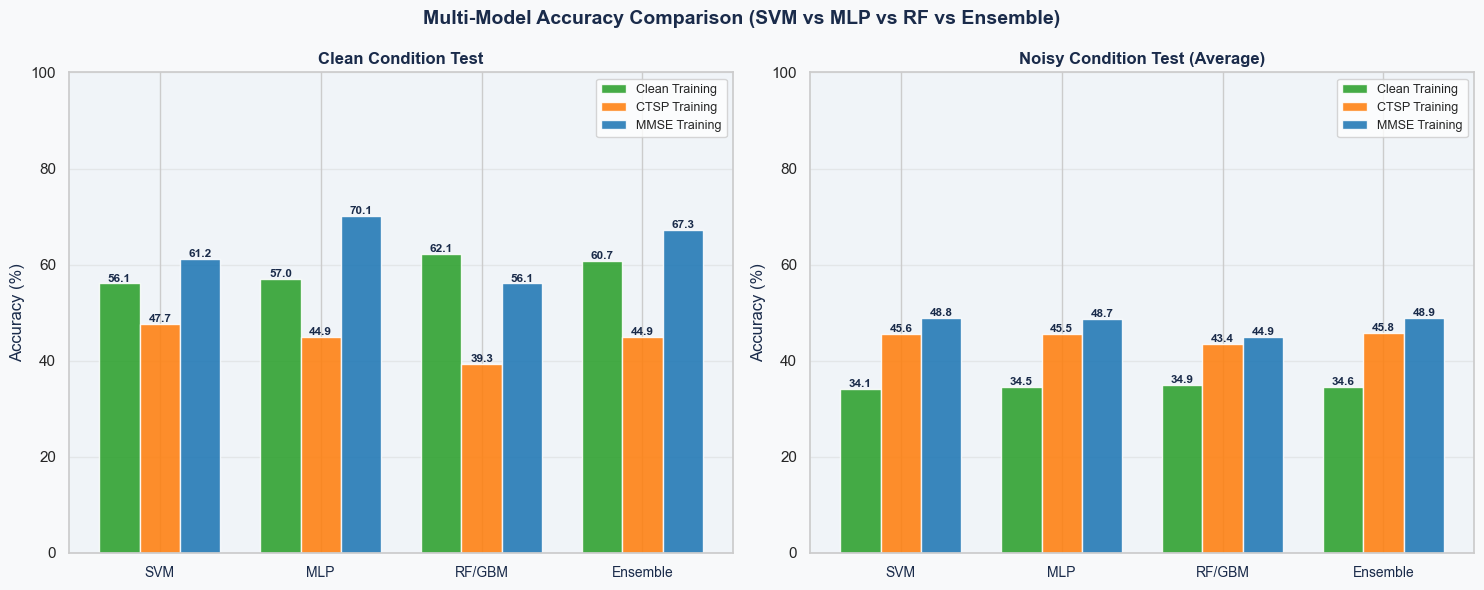

Saved: presentation_plots\Model_Comparison_Bar.png


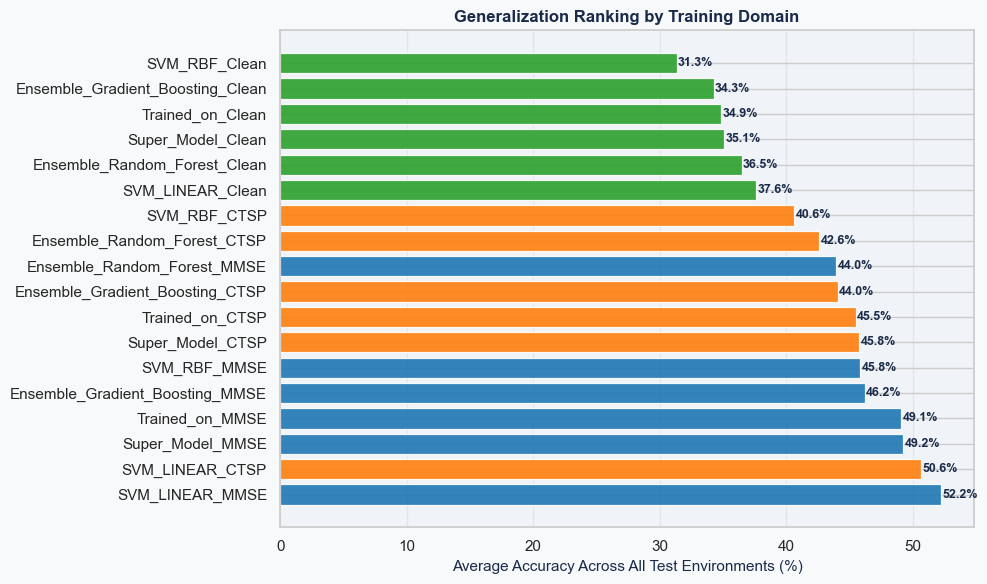

Saved: presentation_plots\Generalization_Ranking.png


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings('ignore')

RESULTS_DIR = "evaluation_results"
OUT_DIR = "presentation_plots"
os.makedirs(OUT_DIR, exist_ok=True)

NAVY = '#1a2b4a'
GREEN = '#2ca02c'
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
RED = '#d62728'

EMOTIONS = ['Anger', 'Boredom', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Neutral']

def load_metrics(filename):
    path_xl = os.path.join(RESULTS_DIR, filename.replace('.csv', '.xlsx'))
    path_csv = os.path.join(RESULTS_DIR, filename.replace('.xlsx', '.csv'))

    if os.path.exists(path_xl):
        return pd.read_excel(path_xl)
    elif os.path.exists(path_csv):
        return pd.read_csv(path_csv)
    else:
        return None

def build_cross_matrix(df, model_col='Training_Model', test_col='Test_Category', acc_col='Overall_Model_Accuracy'):
    df_unique = df[[model_col, test_col, 'Specific_Environment', acc_col]].drop_duplicates()
    pivot = df_unique.pivot_table(index=model_col, columns=test_col, values=acc_col, aggfunc='mean')
    return pivot

def plot_ablation_heatmap(df, model_name='SVM', acc_col='Overall_Model_Accuracy'):
    custom_cmap = LinearSegmentedColormap.from_list(
        'ser', ['#1a0a2e', '#2d1b69', '#1f77b4', '#4dc9f6', '#aaff80', '#ffff00'], N=256)

    try:
        pivot = build_cross_matrix(df, acc_col=acc_col)
    except Exception as e:
        print(f"Could not build pivot table for {model_name}: {e}")
        return

    if pivot.values.max() <= 1.0:
        pivot = pivot * 100

    fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f4f8')

    im = ax.imshow(pivot.values, cmap=custom_cmap, aspect='auto', vmin=pivot.values.min(), vmax=pivot.values.max())
    
    ax.grid(False)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
    cbar.set_label('Accuracy (%)', fontsize=10, color=NAVY)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8.5, color=NAVY)
    ax.set_yticklabels(pivot.index, fontsize=9, color=NAVY, fontweight='bold')
    ax.set_xlabel('Testing Environment', color=NAVY, fontsize=11)
    ax.set_ylabel('Training Domain', color=NAVY, fontsize=11)
    ax.set_title(f'{model_name} Cross-Condition Ablation Matrix', fontweight='bold', color=NAVY)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            text_col = 'white' if v < 40 else 'black'
            fw = 'bold' if i == j else 'normal'
            ax.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=8, color=text_col, fontweight=fw)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, f'Ablation_Heatmap_{model_name}.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_0db_per_emotion(df_super, acc_col='F1_Score'):
    df_0 = df_super[df_super['Specific_Environment'].str.contains('0dB', na=False)]
    df_0 = df_0[~df_0['Emotion_Class'].str.upper().isin(['MACRO AVG', 'WEIGHTED AVG', 'ACCURACY'])]

    if df_0.empty:
        return

    if df_0[acc_col].max() <= 1.0:
        df_0 = df_0.copy()
        df_0[acc_col] = df_0[acc_col] * 100

    test_cats = sorted(df_0['Test_Category'].unique())
    train_models = df_0['Training_Model'].unique()

    preferred_trains = ['Super_Model_Clean', 'Super_Model_CTSP', 'Super_Model_MMSE']
    trains_to_plot = [m for m in preferred_trains if m in train_models]
    if not trains_to_plot:
        trains_to_plot = list(train_models[:3])

    train_colors = [GREEN, ORANGE, BLUE]
    train_labels = [m.replace('Super_Model_', '').replace('_', ' ') for m in trains_to_plot]

    fig, axes = plt.subplots(1, len(test_cats), figsize=(6*len(test_cats), 6), facecolor='#f8f9fa')
    if len(test_cats) == 1:
        axes = [axes]

    fig.suptitle('Per-Emotion F1 Score at 0 dB SNR (Stress Test)', fontsize=14, fontweight='bold', color=NAVY, y=1.01)

    for ax, cat in zip(axes, test_cats):
        ax.set_facecolor('#f0f4f8')
        df_cat = df_0[df_0['Test_Category'] == cat]
        x = np.arange(7)
        w = 0.25

        for i, (model, col, label) in enumerate(zip(trains_to_plot, train_colors, train_labels)):
            df_m = df_cat[df_cat['Training_Model'] == model]
            f1_vals = []
            for emo in EMOTIONS:
                row = df_m[df_m['Emotion_Class'].str.contains(emo, case=False, na=False)]
                f1_vals.append(row[acc_col].mean() if not row.empty else 0.0)
            
            bars = ax.bar(x + (i - 1)*w, f1_vals, w, color=col, alpha=0.85, label=label, edgecolor='white', linewidth=0.8)
            for bar, v in zip(bars, f1_vals):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, f'{v:.0f}', ha='center', fontsize=7, color=NAVY)

        ax.set_xticks(x)
        ax.set_xticklabels(EMOTIONS, rotation=25, ha='right', fontsize=9, color=NAVY)
        ax.set_title(cat, fontweight='bold', color=NAVY)
        ax.set_ylabel('F1-Score (%)' if ax == axes[0] else '', color=NAVY)
        ax.set_ylim(0, 95)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.35)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Per_Emotion_F1_0dB.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_model_comparison_bar(dfs_labels, acc_col='Overall_Model_Accuracy'):
    domains = ['Clean', 'CTSP', 'MMSE']
    domain_cols = [GREEN, ORANGE, BLUE]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#f8f9fa')
    fig.suptitle('Multi-Model Accuracy Comparison (SVM vs MLP vs RF vs Ensemble)', fontsize=14, fontweight='bold', color=NAVY)

    for ax, test_type, title in zip(axes, ['Clean', 'Noisy'], ['Clean Condition Test', 'Noisy Condition Test (Average)']):
        model_names = []
        domain_accs = {d: [] for d in domains}

        for df, model_label in dfs_labels:
            if df is None:
                continue
            model_names.append(model_label)
            df_acc = df[['Training_Model', 'Test_Category', 'Specific_Environment', acc_col]].drop_duplicates()

            for domain in domains:
                if test_type == 'Clean':
                    subset = df_acc[df_acc['Test_Category'].str.contains('Clean', na=False)]
                else:
                    subset = df_acc[~df_acc['Test_Category'].str.contains('Clean', na=False)]
                    
                subset = subset[subset['Training_Model'].str.contains(domain, case=False, na=False)]

                if not subset.empty:
                    val = subset[acc_col].mean()
                    val = val * 100 if val <= 1.0 else val
                    domain_accs[domain].append(val)
                else:
                    domain_accs[domain].append(0.0)

        x = np.arange(len(model_names))
        w = 0.25
        ax.set_facecolor('#f0f4f8')
        
        for i, (domain, col) in enumerate(zip(domains, domain_cols)):
            bars = ax.bar(x + (i-1)*w, domain_accs[domain], w, color=col, alpha=0.88, label=f'{domain} Training', edgecolor='white')
            for bar, v in zip(bars, domain_accs[domain]):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, f'{v:.1f}', ha='center', fontsize=8.5, fontweight='bold', color=NAVY)

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=10, color=NAVY)
        ax.set_title(title, fontweight='bold', color=NAVY)
        ax.set_ylabel('Accuracy (%)', color=NAVY)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.35)
        ax.set_ylim(0, 100)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Model_Comparison_Bar.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def plot_generalization_ranking(dfs_labels, acc_col='Overall_Model_Accuracy'):
    all_rows = []
    for df, model_label in dfs_labels:
        if df is None:
            continue
            
        df_acc = df[['Training_Model', 'Test_Category', 'Specific_Environment', acc_col]].drop_duplicates()
        
        for _, row in df_acc.iterrows():
            val = row.get(acc_col, np.nan)
            if pd.isna(val):
                continue
            val = val * 100 if val <= 1.0 else val
            all_rows.append({'Model': model_label, 'Training_Domain': row.get('Training_Model', '?'), 'Accuracy': val})

    if not all_rows:
        return

    combined = pd.DataFrame(all_rows)
    ranking = (combined.groupby('Training_Domain')['Accuracy'].mean().sort_values(ascending=False).reset_index())

    def domain_color(name):
        n = str(name).upper()
        if 'MMSE' in n: return BLUE
        if 'CTSP' in n: return ORANGE
        if 'CLEAN' in n: return GREEN
        return RED

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f4f8')
    colors = [domain_color(d) for d in ranking['Training_Domain']]
    
    bars = ax.barh(ranking['Training_Domain'], ranking['Accuracy'], color=colors, edgecolor='white', linewidth=0.9, alpha=0.9)
    ax.set_xlabel('Average Accuracy Across All Test Environments (%)', color=NAVY, fontsize=11)
    ax.set_title('Generalization Ranking by Training Domain', fontweight='bold', color=NAVY)
    ax.grid(axis='x', alpha=0.35)
    
    for bar, v in zip(bars, ranking['Accuracy']):
        ax.text(v + 0.1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold', color=NAVY)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Generalization_Ranking.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

if __name__ == '__main__':
    df_mlp = load_metrics('Comprehensive_Metrics.xlsx')
    df_svm = load_metrics('Comprehensive_SVM_Metrics.xlsx')
    df_ensemble = load_metrics('Comprehensive_Ensemble_Metrics.xlsx')
    df_super = load_metrics('Comprehensive_Super_Model_Metrics.xlsx')

    for df, name in [(df_svm, 'SVM'), (df_mlp, 'MLP'), (df_ensemble, 'Ensemble'), (df_super, 'Super_Model')]:
        if df is not None:
            plot_ablation_heatmap(df, model_name=name)

    if df_super is not None:
        plot_0db_per_emotion(df_super)

    dfs_with_labels = [(df_svm, 'SVM'), (df_mlp, 'MLP'), (df_ensemble, 'RF/GBM'), (df_super, 'Ensemble')]
    available = [(df, lbl) for df, lbl in dfs_with_labels if df is not None]
    
    if available:
        plot_model_comparison_bar(available)
        plot_generalization_ranking(available)

### Final analysis

Generating Final Presentation Plots...


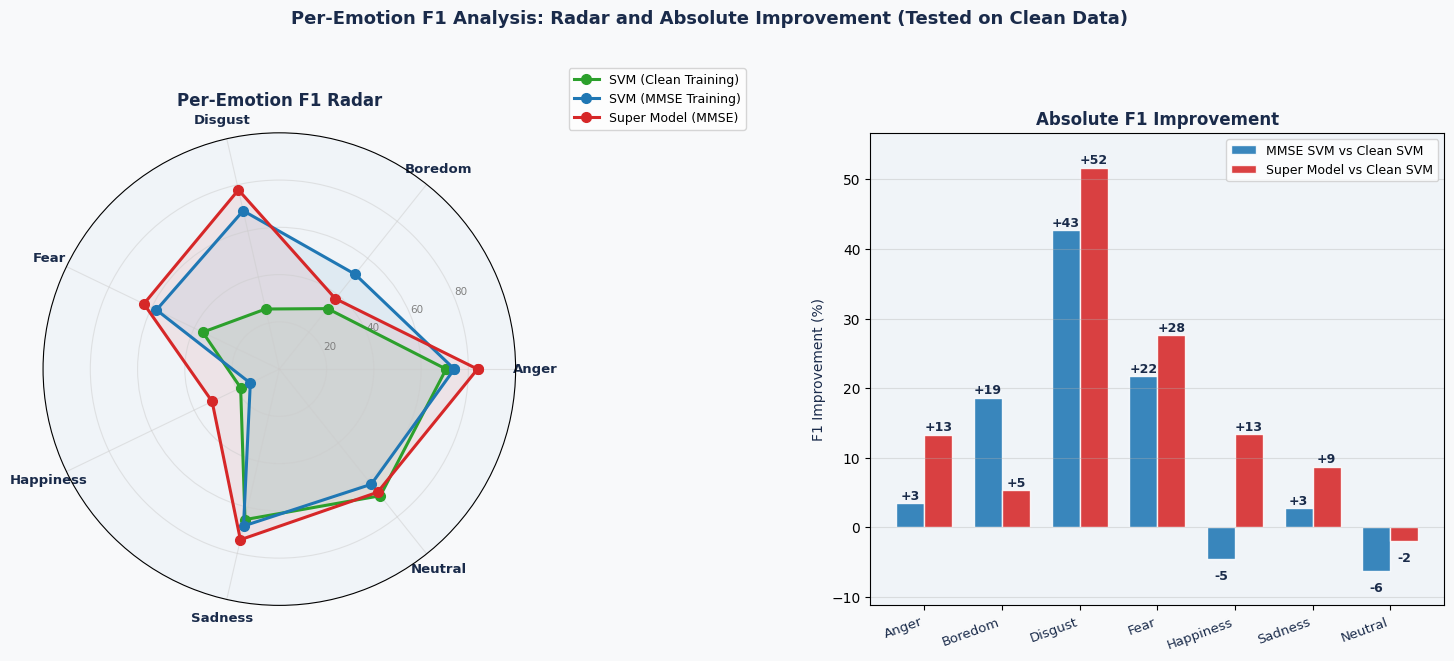

Saved: presentation_plots\Final_Plot_1_Radar_and_Improvement.png


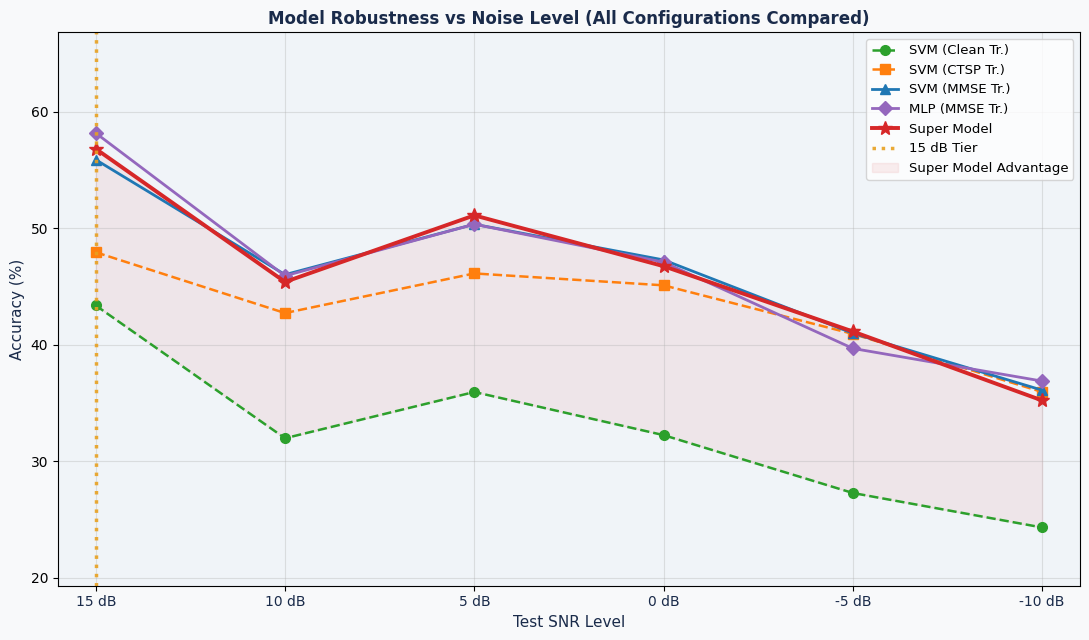

Saved: presentation_plots\Final_Plot_2_SNR_Robustness.png


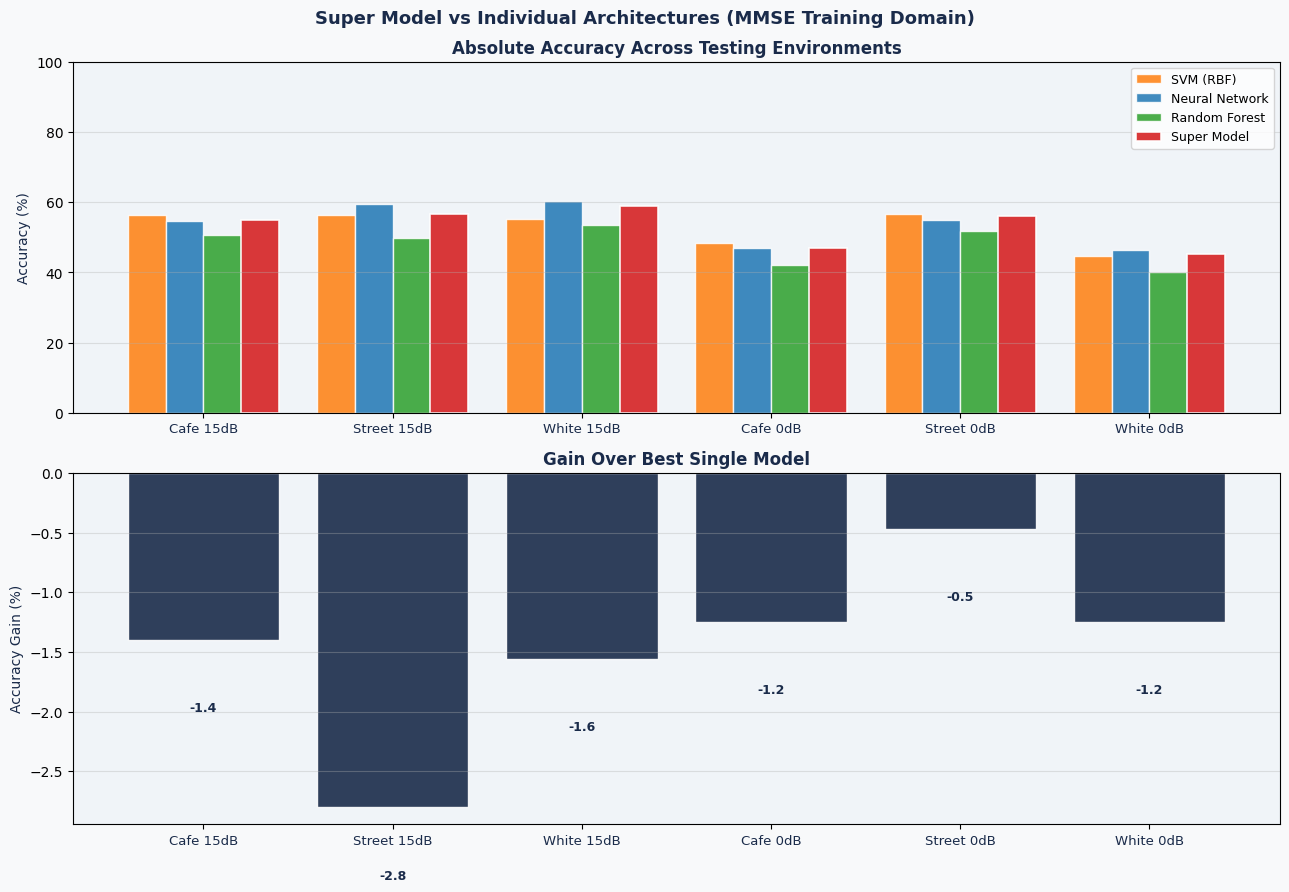

Saved: presentation_plots\Final_Plot_3_Ensemble_Gain.png
All plots generated and saved successfully.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

RESULTS_DIR = "evaluation_results"
OUT_DIR = "presentation_plots"

os.makedirs(OUT_DIR, exist_ok=True)

NAVY = '#1a2b4a'
GOLD = '#E8A020'
RED = '#d62728'
GREEN = '#2ca02c'
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'

EMOTIONS = ['Anger', 'Boredom', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Neutral']

def load_metrics_file(filename):
    path_xl = os.path.join(RESULTS_DIR, filename.replace('.csv', '.xlsx'))
    path_csv = os.path.join(RESULTS_DIR, filename.replace('.xlsx', '.csv'))

    if os.path.exists(path_xl):
        return pd.read_excel(path_xl)
    elif os.path.exists(path_csv):
        return pd.read_csv(path_csv)
    return None

def extract_per_emotion_f1(dataframe, training_model, test_category):
    if dataframe is None:
        return [0] * 7
        
    subset = dataframe[(dataframe['Training_Model'].str.contains(training_model, case=False, na=False)) & 
                       (dataframe['Test_Category'].str.contains(test_category, case=False, na=False)) & 
                       (~dataframe['Emotion_Class'].str.upper().isin(['MACRO AVG', 'WEIGHTED AVG', 'ACCURACY']))]
    
    if subset.empty:
        return [0] * 7
        
    f1_values = []
    for emotion in EMOTIONS:
        emotion_row = subset[subset['Emotion_Class'].str.contains(emotion, case=False, na=False)]
        value = emotion_row['F1_Score'].mean() if not emotion_row.empty else 0.0
        f1_values.append(value * 100 if value <= 1.0 else value)
        
    return f1_values

def plot_radar_and_improvement(df_svm, df_super):
    f1_clean = extract_per_emotion_f1(df_svm, 'Clean', 'Clean')
    f1_mmse_svm = extract_per_emotion_f1(df_svm, 'MMSE', 'Clean')
    f1_ensemble = extract_per_emotion_f1(df_super, 'MMSE', 'Clean')

    if sum(f1_clean) == 0:
        return

    models_radar = {
        'SVM (Clean Training)':  {'vals': f1_clean, 'col': GREEN},
        'SVM (MMSE Training)':   {'vals': f1_mmse_svm, 'col': BLUE},
        'Super Model (MMSE)':    {'vals': f1_ensemble, 'col': RED},
    }

    num_vars = len(EMOTIONS)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)] + [0]

    fig = plt.figure(figsize=(15, 6.5), facecolor='#f8f9fa')
    fig.suptitle('Per-Emotion F1 Analysis: Radar and Absolute Improvement (Tested on Clean Data)', fontsize=13, fontweight='bold', color=NAVY, y=1.01)

    ax_radar = fig.add_subplot(1, 2, 1, polar=True)
    ax_radar.set_facecolor('#f0f4f8')
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(EMOTIONS, fontsize=9.5, fontweight='bold', color=NAVY)
    ax_radar.set_ylim(0, 100)
    ax_radar.set_yticks([20, 40, 60, 80])
    ax_radar.set_yticklabels(['20', '40', '60', '80'], fontsize=7.5, color='gray')
    ax_radar.grid(color='#cccccc', alpha=0.5)

    for label, meta in models_radar.items():
        vals_plot = meta['vals'] + [meta['vals'][0]]
        ax_radar.plot(angles, vals_plot, 'o-', lw=2.2, color=meta['col'], ms=7, label=label)
        ax_radar.fill(angles, vals_plot, alpha=0.08, color=meta['col'])

    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=9)
    ax_radar.set_title('Per-Emotion F1 Radar', fontweight='bold', color=NAVY, pad=20)

    ax_bar = fig.add_subplot(1, 2, 2)
    ax_bar.set_facecolor('#f0f4f8')

    imp_mmse = [mm - cl for mm, cl in zip(f1_mmse_svm, f1_clean)]
    imp_ens = [en - cl for en, cl in zip(f1_ensemble, f1_clean)]
    x_pos = np.arange(num_vars)
    width = 0.36
    
    b1 = ax_bar.bar(x_pos - width/2, imp_mmse, width, color=BLUE, alpha=0.88, label='MMSE SVM vs Clean SVM', edgecolor='white')
    b2 = ax_bar.bar(x_pos + width/2, imp_ens, width, color=RED, alpha=0.88, label='Super Model vs Clean SVM', edgecolor='white')

    for bar, val in list(zip(b1, imp_mmse)) + list(zip(b2, imp_ens)):
        ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.15 if val >= 0 else val - 1.5, f'+{val:.0f}' if val > 0 else f'{val:.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold', color=NAVY)

    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(EMOTIONS, rotation=20, ha='right', fontsize=9.5, color=NAVY)
    ax_bar.set_ylabel('F1 Improvement (%)', color=NAVY, fontsize=10)
    ax_bar.set_title('Absolute F1 Improvement', fontweight='bold', color=NAVY)
    ax_bar.legend(fontsize=9)
    ax_bar.grid(axis='y', alpha=0.35)
    
    min_y = min(min(imp_mmse), min(imp_ens)) - 5
    max_y = max(max(imp_mmse), max(imp_ens)) + 5
    ax_bar.set_ylim(min_y if min_y < 0 else 0, max_y)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Final_Plot_1_Radar_and_Improvement.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def get_snr_accuracies(dataframe, model_name):
    if dataframe is None:
        return [0] * 6
        
    snr_levels = [15, 10, 5, 0, -5, -10]
    accuracies = []
    
    for snr in snr_levels:
        subset = dataframe[(dataframe['Training_Model'].str.contains(model_name, case=False, na=False)) & 
                           (dataframe['Specific_Environment'].str.contains(f'{snr}dB'))]
        if not subset.empty:
            val = subset['Overall_Model_Accuracy'].mean()
            accuracies.append(val * 100 if val <= 1.0 else val)
        else:
            accuracies.append(0)
            
    return accuracies

def plot_snr_robustness(df_svm, df_mlp, df_super):
    snr_levels = [15, 10, 5, 0, -5, -10]
    
    models = {
        'SVM (Clean Tr.)': {'vals': get_snr_accuracies(df_svm, 'Clean'), 'style': 'o--', 'col': GREEN, 'lw': 1.8},
        'SVM (CTSP Tr.)':  {'vals': get_snr_accuracies(df_svm, 'CTSP'),  'style': 's--', 'col': ORANGE, 'lw': 1.8},
        'SVM (MMSE Tr.)':  {'vals': get_snr_accuracies(df_svm, 'MMSE'),  'style': '^-',  'col': BLUE, 'lw': 2.0},
        'MLP (MMSE Tr.)':  {'vals': get_snr_accuracies(df_mlp, 'MMSE'), 'style': 'D-',  'col': PURPLE, 'lw': 2.0},
        'Super Model':     {'vals': get_snr_accuracies(df_super, 'MMSE'), 'style': '*-',  'col': RED, 'lw': 2.8},
    }

    if sum(models['SVM (Clean Tr.)']['vals']) == 0:
        return

    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f4f8')

    for name, meta in models.items():
        ax.plot(snr_levels, meta['vals'], meta['style'], color=meta['col'], lw=meta['lw'], ms=10 if '*' in meta['style'] else 7, label=name)

    ax.axvline(x=15, color=GOLD, ls=':', lw=2.5, alpha=0.9, label='15 dB Tier')
    ax.fill_between(snr_levels, models['Super Model']['vals'], models['SVM (Clean Tr.)']['vals'], alpha=0.07, color=RED, label='Super Model Advantage')

    ax.set_xticks(snr_levels)
    ax.set_xticklabels([f'{s} dB' for s in snr_levels], fontsize=10, color=NAVY)
    ax.set_xlabel('Test SNR Level', color=NAVY, fontsize=11)
    ax.set_ylabel('Accuracy (%)', color=NAVY, fontsize=11)
    ax.set_title('Model Robustness vs Noise Level (All Configurations Compared)', fontweight='bold', color=NAVY)
    ax.set_xlim(16, -11)
    
    max_val = max(models['Super Model']['vals'])
    min_val = min(models['SVM (Clean Tr.)']['vals'])
    ax.set_ylim(min_val - 5 if min_val > 5 else 0, max_val + 10 if max_val < 90 else 100)
    
    ax.legend(fontsize=9.5, loc='upper right')
    ax.grid(alpha=0.35)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Final_Plot_2_SNR_Robustness.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

def get_condition_accuracy(dataframe, model_name, environment):
    if dataframe is None:
        return 0
    subset = dataframe[(dataframe['Training_Model'].str.contains(model_name, case=False, na=False)) & 
                       (dataframe['Specific_Environment'].str.contains(environment, case=False, na=False))]
    if not subset.empty:
        val = subset['Overall_Model_Accuracy'].mean()
        return val * 100 if val <= 1.0 else val
    return 0

def plot_ensemble_gain(df_svm, df_mlp, df_rf, df_super):
    conditions = ['Cafe_15dB', 'Street_15dB', 'White_15dB', 'Cafe_0dB', 'Street_0dB', 'White_0dB']
    display_conditions = ['Cafe 15dB', 'Street 15dB', 'White 15dB', 'Cafe 0dB', 'Street 0dB', 'White 0dB']
    
    svm_acc = [get_condition_accuracy(df_svm, 'MMSE', env) for env in conditions]
    mlp_acc = [get_condition_accuracy(df_mlp, 'MMSE', env) for env in conditions]
    rf_acc = [get_condition_accuracy(df_rf, 'MMSE', env) for env in conditions]
    super_acc = [get_condition_accuracy(df_super, 'MMSE', env) for env in conditions]
    
    if sum(super_acc) == 0:
        return

    gains = [sup - max(s, m, r) for sup, s, m, r in zip(super_acc, svm_acc, mlp_acc, rf_acc)]

    fig, axes = plt.subplots(2, 1, figsize=(13, 9), facecolor='#f8f9fa')
    fig.suptitle('Super Model vs Individual Architectures (MMSE Training Domain)', fontsize=13, fontweight='bold', color=NAVY)

    ax_top = axes[0]
    ax_top.set_facecolor('#f0f4f8')
    x_pos = np.arange(len(conditions))
    width = 0.2
    
    ax_top.bar(x_pos - 1.5*width, svm_acc, width, color=ORANGE, alpha=0.85, label='SVM (RBF)', edgecolor='white')
    ax_top.bar(x_pos - 0.5*width, mlp_acc, width, color=BLUE, alpha=0.85, label='Neural Network', edgecolor='white')
    ax_top.bar(x_pos + 0.5*width, rf_acc, width, color=GREEN, alpha=0.85, label='Random Forest', edgecolor='white')
    ax_top.bar(x_pos + 1.5*width, super_acc, width, color=RED, alpha=0.92, label='Super Model', edgecolor='white', linewidth=1.2)
    
    ax_top.set_xticks(x_pos)
    ax_top.set_xticklabels(display_conditions, fontsize=9.5, color=NAVY)
    ax_top.set_ylabel('Accuracy (%)', color=NAVY, fontsize=10)
    ax_top.set_title('Absolute Accuracy Across Testing Environments', fontweight='bold', color=NAVY)
    ax_top.legend(fontsize=9)
    ax_top.grid(axis='y', alpha=0.35)
    ax_top.set_ylim(0, 100)

    ax_bottom = axes[1]
    ax_bottom.set_facecolor('#f0f4f8')
    bar_cols = [RED if g > 0 else NAVY for g in gains]
    
    ax_bottom.bar(range(len(conditions)), gains, color=bar_cols, edgecolor='white', alpha=0.9)
    ax_bottom.axhline(0, color=NAVY, lw=1.2)
    ax_bottom.set_xticks(range(len(conditions)))
    ax_bottom.set_xticklabels(display_conditions, fontsize=9.5, color=NAVY)
    ax_bottom.set_ylabel('Accuracy Gain (%)', color=NAVY, fontsize=10)
    ax_bottom.set_title('Gain Over Best Single Model', fontweight='bold', color=NAVY)
    ax_bottom.grid(axis='y', alpha=0.35)
    
    for i, g in enumerate(gains):
        ax_bottom.text(i, g + (0.15 if g >= 0 else -0.6), f'+{g:.1f}' if g > 0 else f'{g:.1f}', ha='center', fontsize=9, fontweight='bold', color=NAVY)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'Final_Plot_3_Ensemble_Gain.png')
    fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

if __name__ == '__main__':
    print("Generating Final Presentation Plots...")
    df_mlp = load_metrics_file('Comprehensive_Metrics.xlsx')
    df_svm = load_metrics_file('Comprehensive_SVM_Metrics.xlsx')
    df_rf = load_metrics_file('Comprehensive_Ensemble_Metrics.xlsx')
    df_super = load_metrics_file('Comprehensive_Super_Model_Metrics.xlsx')

    plot_radar_and_improvement(df_svm, df_super)
    plot_snr_robustness(df_svm, df_mlp, df_super)
    plot_ensemble_gain(df_svm, df_mlp, df_rf, df_super)
    print("All plots generated and saved successfully.")

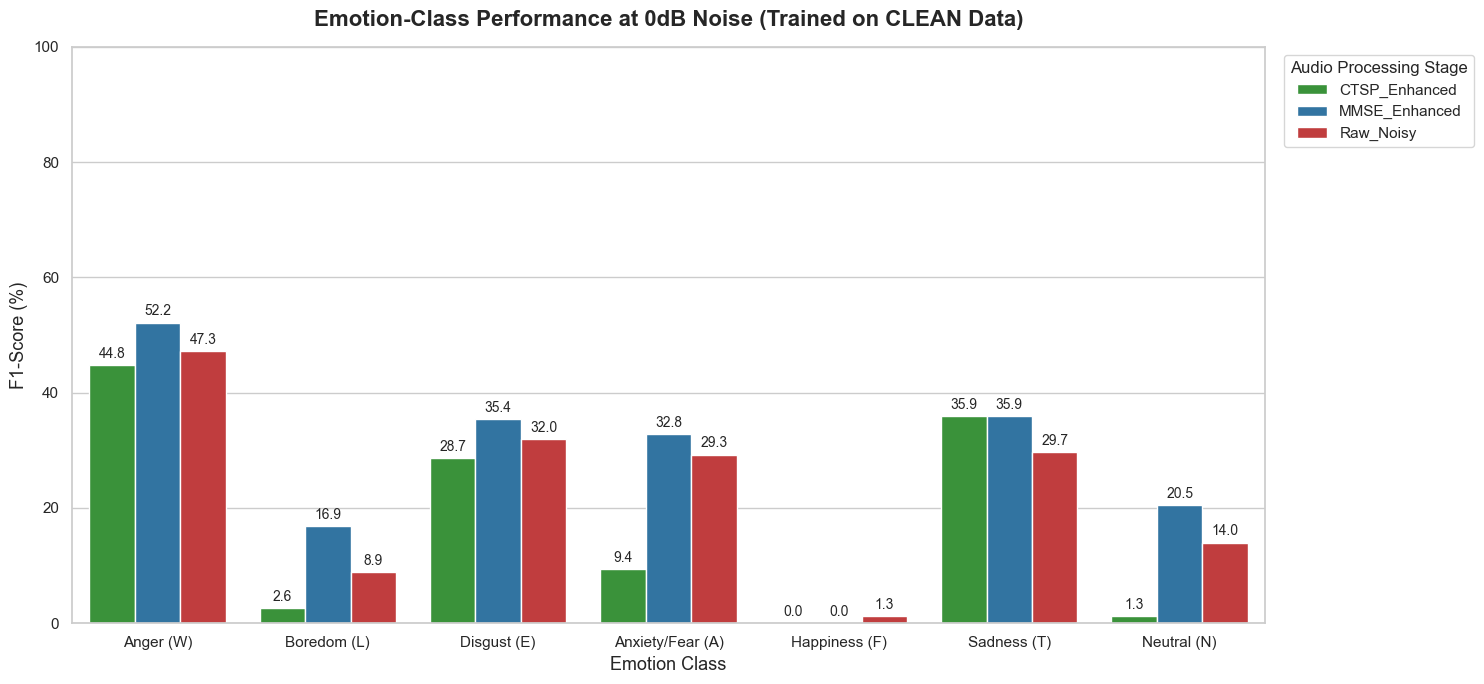

Saved visualization to: presentation_plots\Emotion_Class_0dB_Super_Model_Clean.png


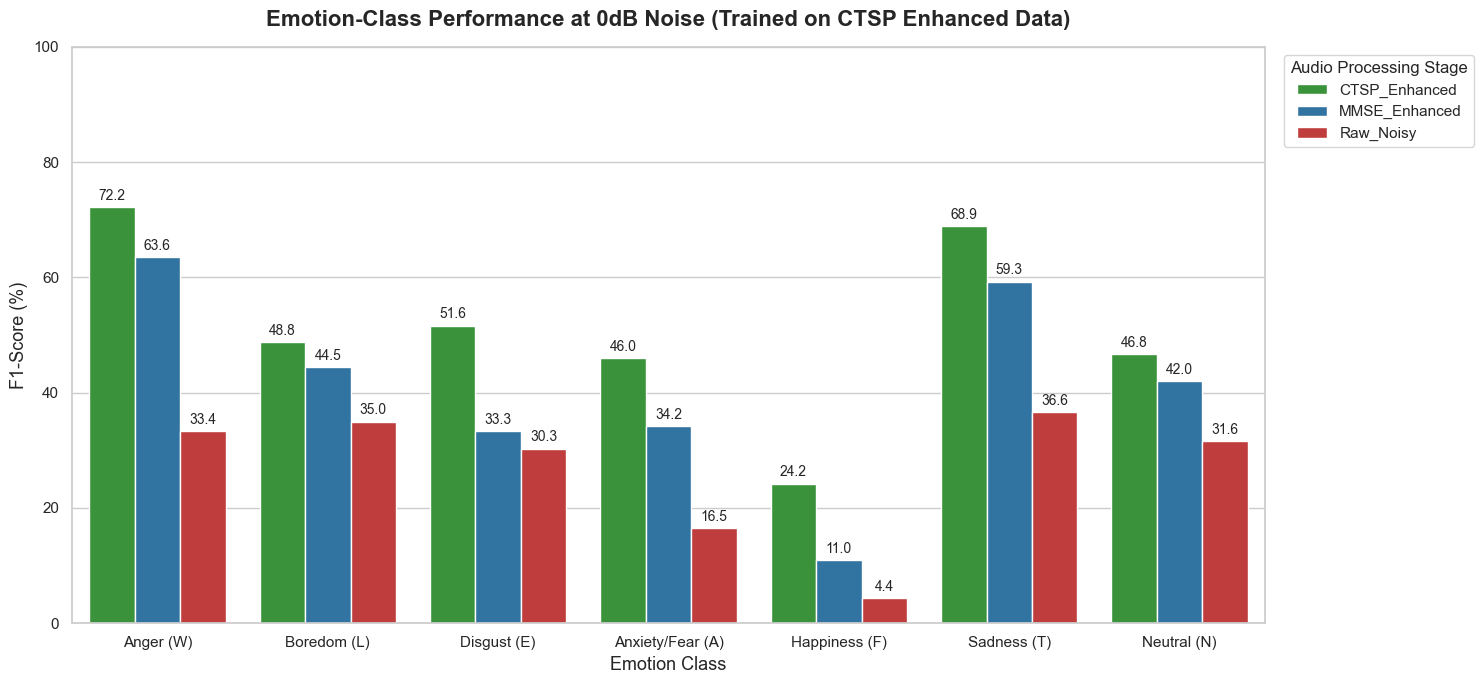

Saved visualization to: presentation_plots\Emotion_Class_0dB_Super_Model_CTSP.png


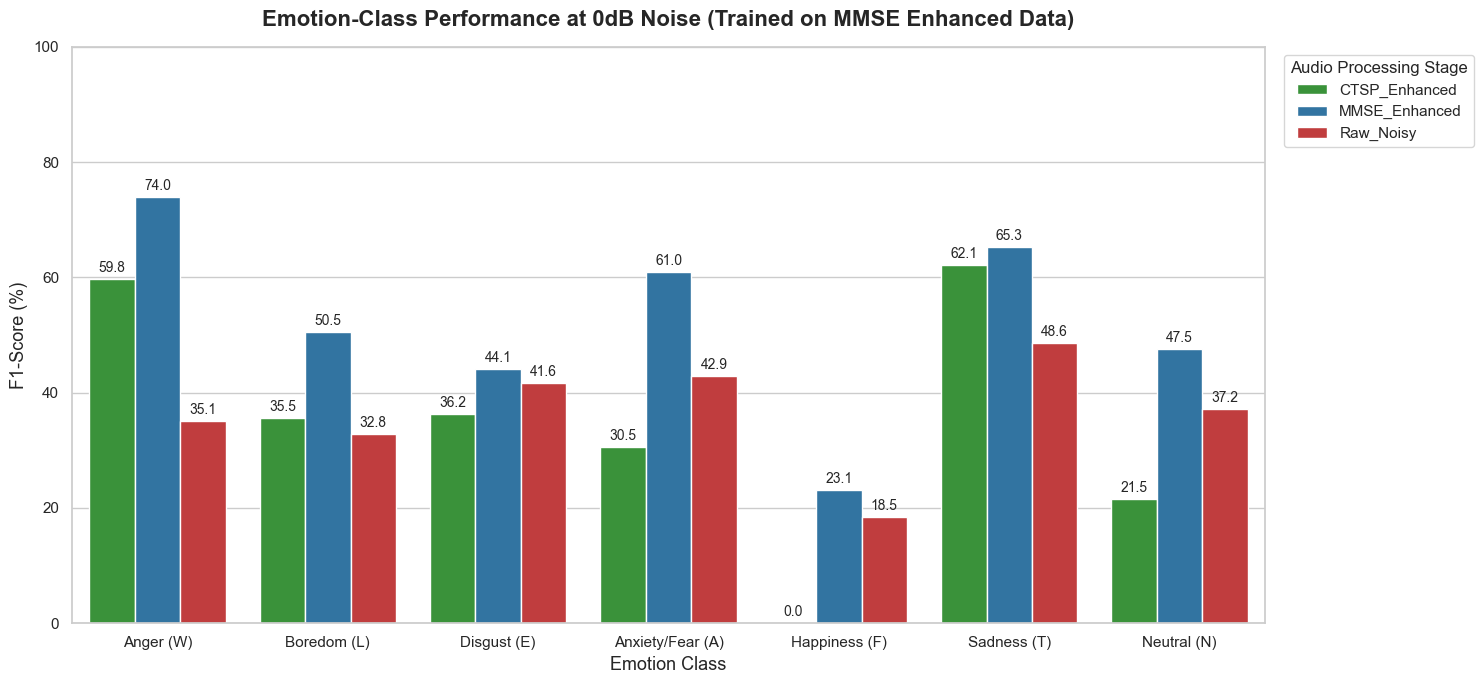

Saved visualization to: presentation_plots\Emotion_Class_0dB_Super_Model_MMSE.png
All emotion-class wise 0dB plots generated successfully.


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

RESULTS_DIR = "evaluation_results"
IMG_DIR = "presentation_plots"
os.makedirs(IMG_DIR, exist_ok=True)

file_path_csv = os.path.join(RESULTS_DIR, "Comprehensive_Super_Model_Metrics.csv")
file_path_excel = os.path.join(RESULTS_DIR, "Comprehensive_Super_Model_Metrics.xlsx")

if os.path.exists(file_path_excel):
    metrics_dataframe = pd.read_excel(file_path_excel)
elif os.path.exists(file_path_csv):
    metrics_dataframe = pd.read_csv(file_path_csv)
else:
    metrics_dataframe = pd.read_csv(os.path.join(RESULTS_DIR, "Comprehensive_Metrics.csv"))

df_0db = metrics_dataframe[metrics_dataframe['Specific_Environment'].str.contains('0dB')]

emotions_only = df_0db[~df_0db['Emotion_Class'].isin(['MACRO AVG', 'WEIGHTED AVG', 'ACCURACY'])]

emotions_only['F1_Score'] = emotions_only['F1_Score'] * 100

averaged_emotions = emotions_only.groupby(['Training_Model', 'Test_Category', 'Emotion_Class'])['F1_Score'].mean().reset_index()

sns.set_theme(style="whitegrid")

training_models_to_plot = {
    'Super_Model_Clean': "Trained on CLEAN Data",
    'Super_Model_CTSP': "Trained on CTSP Enhanced Data",
    'Super_Model_MMSE': "Trained on MMSE Enhanced Data"
}

if 'Super_Model_Clean' not in metrics_dataframe['Training_Model'].unique():
    training_models_to_plot = {
        'Trained_on_Clean': "Trained on CLEAN Data",
        'Trained_on_CTSP': "Trained on CTSP Enhanced Data",
        'Trained_on_MMSE': "Trained on MMSE Enhanced Data"
    }

color_palette = {
    "Raw_Noisy": "#d62728", 
    "CTSP_Enhanced": "#2ca02c", 
    "MMSE_Enhanced": "#1f77b4"
}

emotion_order = [
    "Anger (W)", "Boredom (L)", "Disgust (E)", 
    "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"
]

for model_key, title_suffix in training_models_to_plot.items():
    plot_data = averaged_emotions[averaged_emotions['Training_Model'] == model_key]
    
    plot_data = plot_data[plot_data['Test_Category'].isin(['Raw_Noisy', 'CTSP_Enhanced', 'MMSE_Enhanced'])]
    
    if plot_data.empty:
        print(f"Skipping {model_key} - no matching data found.")
        continue
        
    plt.figure(figsize=(15, 7))
    axis = sns.barplot(
        data=plot_data,
        x='Emotion_Class',
        y='F1_Score',
        hue='Test_Category',
        palette=color_palette,
        order=emotion_order
    )
    
    plt.title(f"Emotion-Class Performance at 0dB Noise ({title_suffix})", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Emotion Class", fontsize=13)
    plt.ylabel("F1-Score (%)", fontsize=13)
    plt.ylim(0, 100)
    plt.legend(title="Audio Processing Stage", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)
    
    for container in axis.containers:
        axis.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
        
    plt.tight_layout()
    
    safe_filename = model_key.replace(" ", "_")
    plot_output_path = os.path.join(IMG_DIR, f"Emotion_Class_0dB_{safe_filename}.png")
    plt.savefig(plot_output_path, dpi=300)
    plt.show()
    
    print(f"Saved visualization to: {plot_output_path}")

print("All emotion-class wise 0dB plots generated successfully.")